In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, roc_auc_score, matthews_corrcoef)
from sklearn.pipeline import Pipeline

work_dir = Path("/kaggle/working")
emb_base = Path("/kaggle/input/datasets/katushkastokom/marlin-vise-check/results/embeddings")

random_seed = 42
print("Готово")

Готово


In [2]:
rows = []
for label_name, label in [("truthful", 1), ("deceptive", 0)]:
    for npy in sorted((emb_base / label_name).glob("*.npy")):
        subject_id = npy.stem.split("_")[0]
        rows.append({
            "video": npy.stem,
            "label": label,
            "label_name": label_name,
            "subject_id": subject_id,
            "embedding_path": str(npy)
        })

full_df = pd.DataFrame(rows)
print("Всего эмбеддингов:", len(full_df))
print(full_df["label_name"].value_counts())
print("Уникальных субъектов:", full_df["subject_id"].nunique())
print("\nКлипов на субъекта (топ-10):")
print(full_df.groupby(["subject_id","label_name"]).size()
      .reset_index(name="n")
      .sort_values("n", ascending=False).head(10).to_string(index=False))

Всего эмбеддингов: 119
label_name
truthful     60
deceptive    59
Name: count, dtype: int64
Уникальных субъектов: 54

Клипов на субъекта (топ-10):
subject_id label_name  n
       s03  deceptive 18
       s25   truthful  8
       s02  deceptive  7
       s01  deceptive  6
       s02   truthful  5
       s15  deceptive  4
       s18  deceptive  4
       s09  deceptive  4
       s03   truthful  3
       s01   truthful  3


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# Данные по субъектам
subject_data = full_df.groupby(["subject_id", "label_name"]).size().reset_index(name="n_clips")

# Топ субъектов по общему числу клипов
top_subjects = (subject_data.groupby("subject_id")["n_clips"].sum()
                .sort_values(ascending=False).head(15).index)

plot_data = subject_data[subject_data["subject_id"].isin(top_subjects)].copy()
plot_data["subject_id"] = pd.Categorical(plot_data["subject_id"],
                                          categories=top_subjects, ordered=True)
plot_data = plot_data.sort_values("subject_id")

# Разбиваем на два класса
dec = plot_data[plot_data["label_name"] == "deceptive"].set_index("subject_id")["n_clips"]
tru = plot_data[plot_data["label_name"] == "truthful"].set_index("subject_id")["n_clips"]

subjects = list(top_subjects)
dec_vals = [dec.get(s, 0) for s in subjects]
tru_vals = [tru.get(s, 0) for s in subjects]

x = np.arange(len(subjects))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, dec_vals, width, color="#E8593C",
               label="Deceptive (ложь)", zorder=3)
bars2 = ax.bar(x + width/2, tru_vals, width, color="#1D9E75",
               label="Truthful (правда)", zorder=3)

# Подписи значений на столбцах
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
                str(int(h)), ha="center", va="bottom", fontsize=9)

for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
                str(int(h)), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(subjects, fontsize=11)
ax.set_ylabel("Количество видеозаписей", fontsize=12)
ax.set_xlabel("Идентификатор субъекта", fontsize=12)
ax.set_title("Распределение видеозаписей по субъектам (топ-15 по числу клипов)",
             fontsize=13, pad=12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_facecolor("#f8f8f8")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(max(dec_vals), max(tru_vals)) + 2)

plt.tight_layout()
plt.savefig("/kaggle/working/subject_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: subject_distribution.png")


In [5]:
def get_data(df):
    """Загружает X, y, groups из датафрейма"""
    X = np.stack([np.load(p) for p in df["embedding_path"]])
    y = df["label"].to_numpy()
    groups = df["subject_id"].to_numpy()
    return X, y, groups

def apply_cap(df, max_clips):
    """Ограничивает число клипов на субъекта"""
    sampled = (df.groupby("subject_id", group_keys=False)
                 .apply(lambda g: g.sample(min(len(g), max_clips),
                                           random_state=random_seed)))
    return sampled.reset_index(drop=True)

def apply_features(X, mode):
    """Применяет разные варианты признаков"""
    half = X.shape[1] // 2
    n_samples = X.shape[0]
    
    if mode == "mean_only":
        return X[:, :half]
    elif mode == "std_only":
        return X[:, half:]
    elif mode == "mean_std":
        return X
    elif mode == "l2_norm":
        return normalize(X, norm="l2")
    elif mode == "pca_50":
        n = min(50, n_samples - 1)
        return PCA(n_components=n, random_state=random_seed).fit_transform(
            StandardScaler().fit_transform(X))
    elif mode == "pca_100":
        n = min(100, n_samples - 1)
        return PCA(n_components=n, random_state=random_seed).fit_transform(
            StandardScaler().fit_transform(X))
    return X

def run_cv(X, y, groups, clf_name, clf_model, n_splits=5):
    """Запускает 5-fold group CV и возвращает метрики"""
    sgkf = StratifiedGroupKFold(n_splits=n_splits,
                                shuffle=True,
                                random_state=random_seed)
    fold_metrics = []
    for tr_idx, te_idx in sgkf.split(X, y, groups=groups):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", clf_model)
        ])
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        y_prob = pipe.predict_proba(X_te)[:, 1]

        fold_metrics.append({
            "accuracy": accuracy_score(y_te, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_te, y_pred),
            "f1_macro": f1_score(y_te, y_pred, average="macro"),
            "auc": roc_auc_score(y_te, y_prob),
            "mcc": matthews_corrcoef(y_te, y_pred),
        })

    fm = pd.DataFrame(fold_metrics)
    return {
        "accuracy": round(fm["accuracy"].mean(), 4),
        "balanced_accuracy": round(fm["balanced_accuracy"].mean(), 4),
        "f1_macro": round(fm["f1_macro"].mean(), 4),
        "auc": round(fm["auc"].mean(), 4),
        "mcc": round(fm["mcc"].mean(), 4),
        "std_accuracy": round(fm["accuracy"].std(), 4),
    }

print("Функции готовы")

Функции готовы


In [6]:
# Конфигурации данных
data_configs = {
    "all_clips":  full_df,
    "cap_3":      apply_cap(full_df, 3),
    "cap_5":      apply_cap(full_df, 5),
}

# Конфигурации признаков
feature_configs = [
    "mean_std",
    "mean_only",
    "std_only",
    "l2_norm",
    "pca_50",
    "pca_100",
]

# Классификаторы
classifiers = {
    "LR":  LogisticRegression(max_iter=5000, class_weight="balanced"),
    "SVM_Lin": SVC(kernel="linear", class_weight="balanced", probability=True),
    "SVM_RBF": SVC(kernel="rbf", class_weight="balanced", probability=True),
    "RF":  RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                   random_state=random_seed),
}

results = []
total = len(data_configs) * len(feature_configs) * len(classifiers)
done = 0

for data_name, df in data_configs.items():
    X_raw, y, groups = get_data(df)
    n_subjects = len(set(groups))

    for feat_name in feature_configs:
        X = apply_features(X_raw, feat_name)

        for clf_name, clf_model in classifiers.items():
            metrics = run_cv(X, y, groups, clf_name, clf_model)
            results.append({
                "data": data_name,
                "features": feat_name,
                "classifier": clf_name,
                "n_videos": len(df),
                "n_subjects": n_subjects,
                **metrics
            })
            done += 1
            if done % 10 == 0 or done == total:
                print(f"[{done}/{total}] {data_name} | {feat_name} | {clf_name} "
                      f"→ bal_acc={metrics['balanced_accuracy']:.3f} "
                      f"auc={metrics['auc']:.3f}")

results_df = pd.DataFrame(results).sort_values("balanced_accuracy",
                                                ascending=False)
results_df.to_csv(work_dir / "all_experiments.csv", index=False)
print("\nВсе эксперименты завершены!")
print(f"Лучший результат:")
print(results_df.head(1)[["data","features","classifier",
                           "balanced_accuracy","auc","mcc"]].to_string(index=False))

/tmp/ipykernel_55/2116129914.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), max_clips),
/tmp/ipykernel_55/2116129914.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), max_clips),


[10/72] all_clips | std_only | SVM_Lin → bal_acc=0.574 auc=0.589
[20/72] all_clips | pca_50 | RF → bal_acc=0.624 auc=0.741
[30/72] cap_3 | mean_only | SVM_Lin → bal_acc=0.475 auc=0.483
[40/72] cap_3 | l2_norm | RF → bal_acc=0.638 auc=0.721
[50/72] cap_5 | mean_std | SVM_Lin → bal_acc=0.581 auc=0.604
[60/72] cap_5 | std_only | RF → bal_acc=0.626 auc=0.764
[70/72] cap_5 | pca_100 | SVM_Lin → bal_acc=0.493 auc=0.595
[72/72] cap_5 | pca_100 | RF → bal_acc=0.420 auc=0.517

Все эксперименты завершены!
Лучший результат:
     data features classifier  balanced_accuracy    auc    mcc
all_clips std_only         RF             0.6676 0.6283 0.3362


In [7]:
print("=== ТОП-15 конфигураций по balanced_accuracy ===\n")
top15 = results_df.head(15)[["data","features","classifier",
                              "n_videos","accuracy","balanced_accuracy",
                              "f1_macro","auc","mcc","std_accuracy"]]
print(top15.to_string(index=False))

print("\n=== Лучшая конфигурация для каждого классификатора ===\n")
best_per_clf = (results_df.groupby("classifier")
                .first()
                .reset_index()[["classifier","data","features",
                                "balanced_accuracy","auc","mcc"]])
print(best_per_clf.to_string(index=False))

print("\n=== Влияние cap на результат (среднее по всем классификаторам) ===\n")
cap_effect = (results_df.groupby("data")[["balanced_accuracy","auc"]]
              .mean().round(4))
print(cap_effect.to_string())

print("\n=== Влияние признаков (среднее по всем классификаторам) ===\n")
feat_effect = (results_df.groupby("features")[["balanced_accuracy","auc"]]
               .mean().round(4)
               .sort_values("balanced_accuracy", ascending=False))
print(feat_effect.to_string())

=== ТОП-15 конфигураций по balanced_accuracy ===

     data features classifier  n_videos  accuracy  balanced_accuracy  f1_macro    auc    mcc  std_accuracy
all_clips std_only         RF       119    0.6387             0.6676    0.6252 0.6283 0.3362        0.2538
    cap_3 std_only         RF        76    0.6871             0.6574    0.6228 0.6975 0.2984        0.1841
    cap_5 std_only         LR        88    0.6490             0.6519    0.6074 0.7107 0.3101        0.0817
    cap_3 mean_std    SVM_RBF        76    0.6594             0.6483    0.6221 0.5098 0.2783        0.1428
    cap_3  l2_norm         RF        76    0.6871             0.6385    0.6303 0.7209 0.3075        0.1620
    cap_3 mean_std         RF        76    0.6728             0.6363    0.6252 0.7324 0.2735        0.1540
    cap_5 std_only         RF        88    0.5922             0.6256    0.5505 0.7641 0.2570        0.1637
all_clips   pca_50         RF       119    0.6104             0.6236    0.5510 0.7413 0.3147  

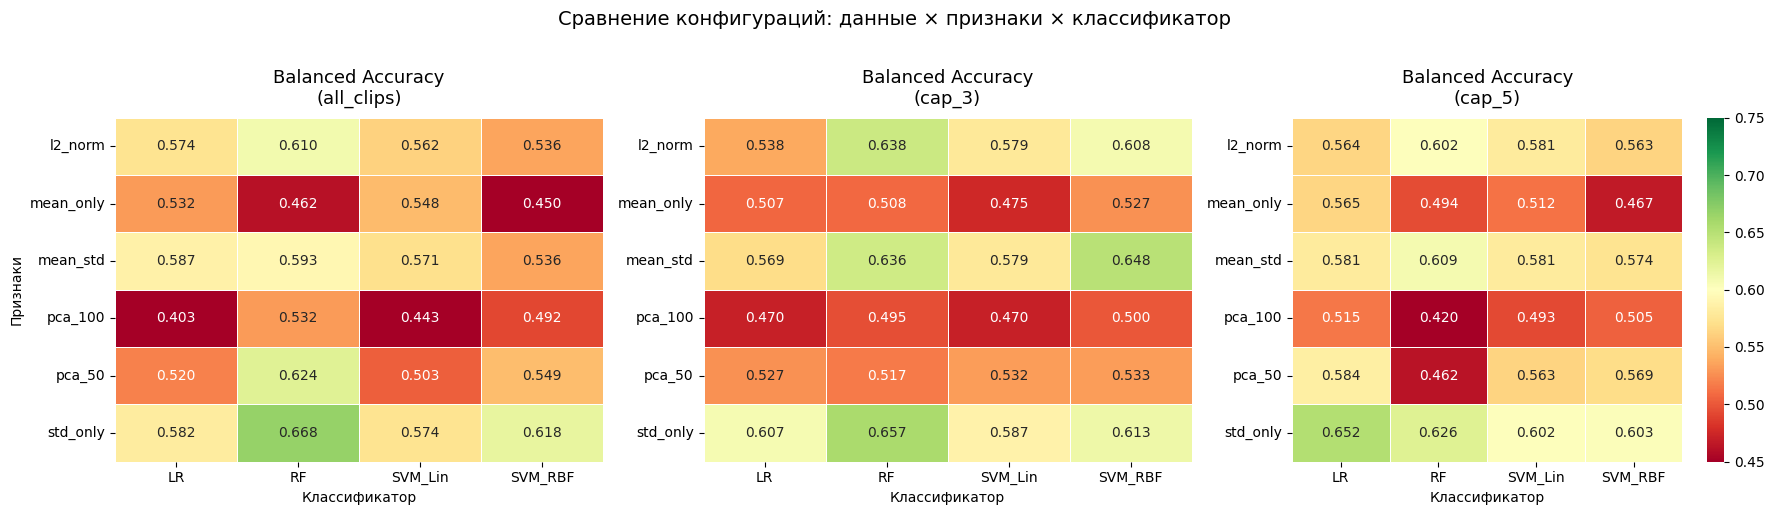

Сохранено: heatmap_experiments.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (data_name, ax) in enumerate(zip(data_configs.keys(), axes)):
    pivot = (results_df[results_df["data"] == data_name]
             .pivot(index="features", columns="classifier",
                    values="balanced_accuracy"))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=0.45, vmax=0.75, ax=ax,
                linewidths=0.5, cbar=idx==2)
    ax.set_title(f"Balanced Accuracy\n({data_name})", fontsize=13, pad=10)
    ax.set_xlabel("Классификатор")
    ax.set_ylabel("Признаки" if idx == 0 else "")

plt.suptitle("Сравнение конфигураций: данные × признаки × классификатор",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(work_dir / "heatmap_experiments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: heatmap_experiments.png")

Лучшая конфигурация: data=all_clips, features=std_only, clf=RF
Balanced accuracy: 0.6676, AUC: 0.6283


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


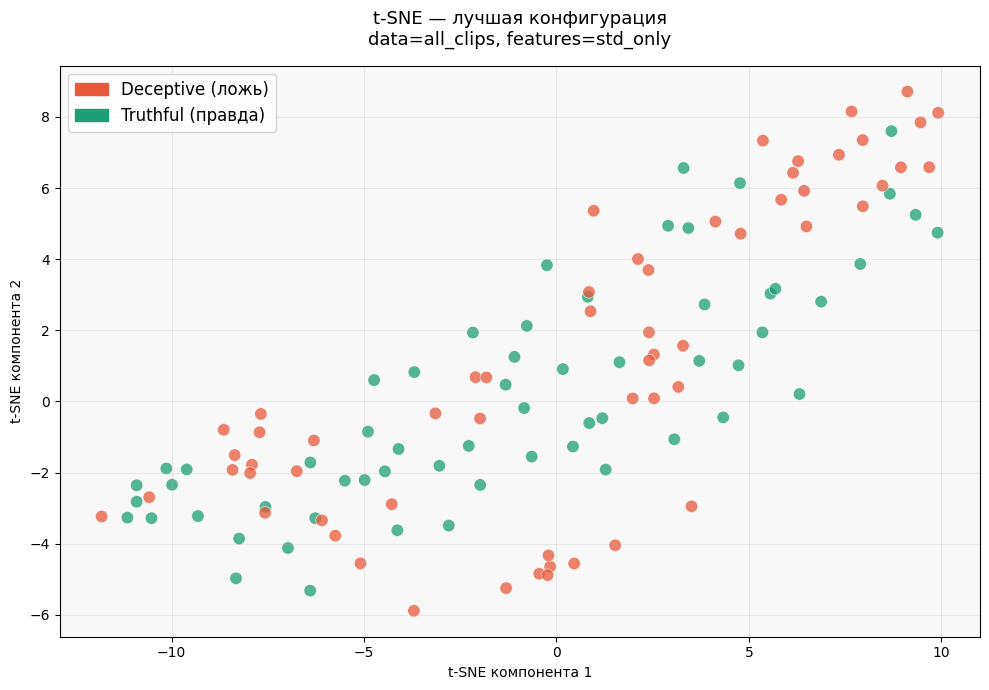

Сохранено: tsne_best_config.png


In [9]:
# Берём лучшую конфигурацию
best = results_df.iloc[0]
print(f"Лучшая конфигурация: data={best['data']}, "
      f"features={best['features']}, clf={best['classifier']}")
print(f"Balanced accuracy: {best['balanced_accuracy']}, AUC: {best['auc']}")

# Готовим данные
best_df = data_configs[best["data"]]
X_raw, y, groups = get_data(best_df)
X_best = apply_features(X_raw, best["features"])

X_scaled = StandardScaler().fit_transform(X_best)
tsne = TSNE(n_components=2, perplexity=20, random_state=42,
            n_iter=1000, learning_rate="auto", init="pca")
X_2d = tsne.fit_transform(X_scaled)

colors = ["#E8593C" if l == 0 else "#1D9E75" for l in y]
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=80,
           alpha=0.75, edgecolors="white", linewidths=0.5)

patch_dec = mpatches.Patch(color="#E8593C", label="Deceptive (ложь)")
patch_tru = mpatches.Patch(color="#1D9E75", label="Truthful (правда)")
ax.legend(handles=[patch_dec, patch_tru], fontsize=12)
ax.set_title(f"t-SNE — лучшая конфигурация\n"
             f"data={best['data']}, features={best['features']}",
             fontsize=13, pad=15)
ax.set_xlabel("t-SNE компонента 1")
ax.set_ylabel("t-SNE компонента 2")
ax.grid(True, alpha=0.2)
ax.set_facecolor("#f8f8f8")
plt.tight_layout()
plt.savefig(work_dir / "tsne_best_config.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: tsne_best_config.png")

In [7]:
import matplotlib.pyplot as plt
import numpy as np

configs = [
    "MARLIN vit_small\n(mean+std pooling)",
    "MARLIN vit_base\n(mean+std pooling)",
    "MARLIN vit_base\n(std pooling)",
]

bal_acc = [0.487, 0.587, 0.668]
auc     = [0.544, 0.618, 0.628]

x = np.arange(len(configs))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5.5))

COLOR_BA  = "#3A6FAE"
COLOR_AUC = "#E07B39"

bars1 = ax.bar(x - width/2, bal_acc, width,
               color=COLOR_BA, label="Balanced Accuracy", zorder=3)
bars2 = ax.bar(x + width/2, auc, width,
               color=COLOR_AUC, label="AUC-ROC", zorder=3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#1A1A2E")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#1A1A2E")

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.2, alpha=0.7,
           label="Случайное угадывание (0.5)")

ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=11)
ax.set_ylabel("Значение метрики", fontsize=12)
ax.set_ylim(0.38, 0.78)
ax.legend(fontsize=10, loc="upper left", framealpha=0.9)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_facecolor("#f8f8f8")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/tmp/model_comparison_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: model_comparison_fixed.png")
